# PelakX — hands-on walkthrough

**Multilingual license plate intelligence.** This notebook takes you from a
plate *string* to a fully processed video, and shows you how to tune it for
your own hardware.

Run the cells in order. Sections 1–4 need **no models and no video** — they
exercise the grammar engine, which is the part that makes PelakX different
from a plain `YOLO → OCR → print` demo.

| # | Section | Needs |
|---|---|---|
| 1 | Setup and environment check | nothing |
| 2 | The grammar engine | nothing |
| 3 | Temporal voting | nothing |
| 4 | Add your own country | nothing |
| 5 | Quality gate | OpenCV |
| 6 | Run the full pipeline on a video | detector + OCR + a video |
| 7 | Where the frame budget goes | same |
| 8 | Tuning: is it real time? | same |
| 9 | Explore the results | a completed run |
| 10 | Persian round-trip test | `pelakx[fa]` |

## 1. Setup and environment check

In [1]:
# Run PelakX straight from the repo without installing it.
import sys, os
from pathlib import Path

REPO = Path.cwd()
if not (REPO / "src" / "pelakx").is_dir():          # notebook opened from notebooks/
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

# Ultralytics auto-installs missing packages and that can upgrade numpy
# underneath a working environment. Turn it off before importing anything.
os.environ["YOLO_AUTOINSTALL"] = "false"

import pelakx
print("PelakX", pelakx.__version__, "| repo:", REPO)

PelakX 0.1.0 | repo: C:\1\1_پروژه\تشخیص پلاکو ماشین\PelakX


In [2]:
# What is installed, and what device will `device: auto` pick?
from pelakx import ocr
from pelakx.grammar import registry
from pelakx.runtime import describe_device

print("device (auto) ->", describe_device("auto"))
print("OCR engines   ->", ocr.available() or "none beyond the built-in test double")
print("grammars      ->", len(registry.codes()), ":", ", ".join(registry.codes()))

device (auto) -> cpu  (auto — no GPU detected)
OCR engines   -> ['echo', 'fast_plate', 'hezar_fa']
grammars      -> 12 : AE, BR, DE, ES, FR, GB, IN, IR, IT, NL, TR, US


Missing something? Each extra is optional and independent:

```bash
pip install -e ".[detect]"   # YOLO26 vehicle + plate detection (torch)
pip install -e ".[onnx]"     # fast CPU plate detector + Latin plate OCR
pip install -e ".[fa]"       # Persian plate OCR + RTL text rendering
pip install -e ".[dash]"     # dashboard
```

`pelakx doctor` prints the same thing from a terminal, with the exact fix for
anything missing.

## 2. The grammar engine

An OCR engine returns a noisy string. The country grammar says what a *legal*
plate looks like. PelakX uses the second to correct the first.

In [3]:
from pelakx.grammar import parse, registry

ir = registry.get("IR")

# The word "ایران" is printed on the plate but is not part of the reading, and
# the digits are Persian-Indic. Both are handled by the grammar file.
read = parse("۱۲ ب ۳۴۵ ایران ۱۱", ir, ocr_confidence=0.90)

print("canonical  ", read.canonical)
print("display    ", read.display)
print("layout     ", read.layout_id)
print("fields     ", read.fields)
print("confidence ", f"{read.confidence:.1%}", "| valid:", read.valid)

canonical   12ب34511
display     12 ب 345 | ایران 11
layout      civilian
fields      {'left': '12', 'letter': 'ب', 'right': '345', 'province': '11'}
confidence  92.0% | valid: True


In [4]:
# Confusion repair: slot 6 of an Iranian plate must be a digit. OCR gave "I".
# Instead of discarding the reading, the grammar substitutes 1 — and charges
# for it, so a repaired plate never outranks a clean one.
clean    = parse("12ب34511", ir, ocr_confidence=0.90)
repaired = parse("12ب345I1", ir, ocr_confidence=0.90)

print(f"clean    {clean.canonical}  conf={clean.confidence:.3f}  repairs={clean.repairs}")
print(f"repaired {repaired.canonical}  conf={repaired.confidence:.3f}  repairs={repaired.repairs}")
print("same plate:", clean.canonical == repaired.canonical)

clean    12ب34511  conf=0.920  repairs=0
repaired 12ب34511  conf=0.877  repairs=1
same plate: True


In [5]:
# Structural validators. Iran's province code ("ایران XX") must be 10..99.
for plate in ["12ب34555", "12ب34509"]:
    r = parse(plate, ir, ocr_confidence=0.90)
    print(f"{plate}  province={r.fields.get('province'):>3}  "
          f"conf={r.confidence:.3f}  valid={r.valid}")

12ب34555  province= 55  conf=0.920  valid=True
12ب34509  province= 09  conf=0.800  valid=False


In [6]:
# Auto-detect the issuing country. Every grammar competes; the best *valid*
# parse wins. 12 countries ship in the box.
from pelakx.grammar import identify_country

specs = registry.all_specs()
for text in ["AB12CDE", "1234BCD", "AA-123-BB", "MH12AB1234", "ABC1D23", "12ب34511", "34ABC123"]:
    r = identify_country(text, specs, ocr_confidence=0.92)
    if r:
        print(f"{text:12s} -> {r.country}  {r.display:22s} layout={r.layout_id:12s} {r.confidence:.0%}")
    else:
        print(f"{text:12s} -> no country grammar accepts this")

AB12CDE      -> GB  AB12 CDE               layout=current      93%
1234BCD      -> ES  1234 BCD               layout=modern       93%
AA-123-BB    -> FR  AA-123-BB              layout=siv          93%
MH12AB1234   -> IN  MH 12 AB 1234          layout=standard     92%
ABC1D23      -> BR  ABC1D23                layout=mercosul     92%
12ب34511     -> IR  12 ب 345 | ایران 11    layout=civilian     94%
34ABC123     -> TR  34 ABC 123             layout=standard     94%


### Single country vs auto

Auto is opt-in. Pointing PelakX at one country is both the default and the
cheaper path — it matches one grammar instead of twelve, and the grammar layer
costs well under a millisecond either way (you will see this in §7).

```bash
pelakx run traffic.mp4 --country IR      # only Iranian grammars are considered
pelakx run traffic.mp4 --country auto    # all 12 compete for every reading
```

Use a fixed country whenever you know it: a tighter alphabet means fewer ways
for OCR to be wrong, which is worth more than the compute you save.

## 3. Temporal voting

A per-frame demo prints a different string every frame. PelakX treats every
frame as *evidence about one tracked vehicle*.

In [7]:
from pelakx.fusion import TrackConsensus

# Five sightings of one car. Every one has a different single-character error;
# not one of them is fully correct.
sightings = ["12ب34511", "12ب34521", "12ب34511", "12ب94511", "12ب34511"]

consensus = TrackConsensus(ir)
for text in sightings:
    consensus.add(parse(text, ir, ocr_confidence=0.82))

result = consensus.result()
print("frames saw   :", sightings)
print("consensus    :", result.canonical, f"({result.confidence:.1%})")
print()
for c in consensus.explain()["candidates"]:
    print(f"  {c['canonical']:12s} votes={c['votes']}  share={c['share']:.0%}")

frames saw   : ['12ب34511', '12ب34521', '12ب34511', '12ب94511', '12ب34511']
consensus    : 12ب34511 (81.9%)

  12ب34511     votes=3  share=60%
  12ب34521     votes=1  share=20%
  12ب94511     votes=1  share=20%


In [8]:
# Blurry frames count less. Quality is a multiplier on every vote.
c = TrackConsensus(ir)
c.add(parse("12ب34511", ir, ocr_confidence=0.9), quality=1.00)   # sharp crop
c.add(parse("12ب34599", ir, ocr_confidence=0.9), quality=0.05)   # blurry crop
print("winner:", c.result().canonical, "— the sharp frame carries the vote")

winner: 12ب34511 — the sharp frame carries the vote


## 4. Add your own country

A country is a YAML file. No Python, no fork. Here is one built at runtime.

In [9]:
import yaml
from pelakx.grammar.spec import CountrySpec
from pelakx.grammar import registry

# Pakistan: "ABC-1234" — 3 letters, 4 digits.
pk_yaml = '''
code: PK
iso3: PAK
name_en: Pakistan
name_native: Pakistan
script: latin
text_direction: ltr
read_order: ltr
digit_style: latin
ocr_engines: { preferred: [fast_plate], fallback: [paddle, easyocr] }
alphabet:
  digits: "0123456789"
  letters: [A, B, C, D, E, F, G, H, I, J, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y, Z]
layouts:
  - id: standard
    name_en: Standard private plate
    slots: "LLLDDDD"
    groups: { series: [0, 3], serial: [3, 7] }
    display: "{series}-{serial}"
    canonical: "{series}{serial}"
    priority: 100
confusions:
  to_digit:  { "O": "0", "I": "1", "S": "5", "B": "8", "G": "6" }
  to_letter: { "0": "O", "1": "I", "5": "S", "8": "B", "6": "G" }
validators: []
'''

registry.register_spec(CountrySpec.from_dict(yaml.safe_load(pk_yaml)))
pk = registry.get("PK")

print(parse("ABC1234", pk, ocr_confidence=0.9).display)
print(parse("ABC1Z34", pk, ocr_confidence=0.9).display, "  <- Z repaired to 2 in a digit slot")
print("registry now has", len(registry.codes()), "countries:", ", ".join(registry.codes()))

ABC-1234
ABC1Z34   <- Z repaired to 2 in a digit slot
registry now has 13 countries: AE, BR, DE, ES, FR, GB, IN, IR, IT, NL, PK, TR, US


To make it permanent, write the same YAML to `configs/countries/pk.yaml`
(or `~/.pelakx/countries/`, or anywhere in `$PELAKX_COUNTRIES`) and PelakX
picks it up on the next run. `pelakx new-country PK` scaffolds it for you.

Full guide: [`docs/ADDING_A_COUNTRY.md`](../docs/ADDING_A_COUNTRY.md)

## 5. The quality gate

Running OCR on every plate box of every frame is the biggest waste of CPU in a
naive pipeline. Most crops are too small, too blurry or too skewed to ever be
read correctly — and when they *do* produce a reading, it poisons the vote.

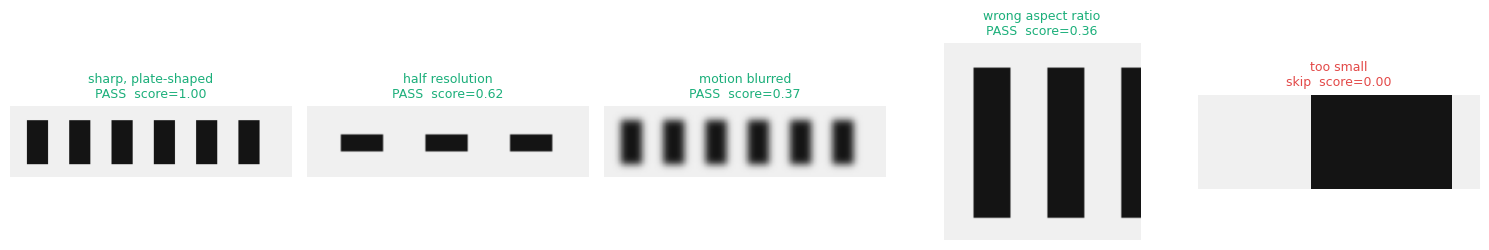

In [10]:
import cv2, numpy as np
import matplotlib.pyplot as plt
from pelakx.quality import QualityGate

def fake_plate(width=200, height=50, blur=0):
    img = np.full((height, width, 3), 240, np.uint8)
    for i in range(6):
        x = 12 + i * 30
        cv2.rectangle(img, (x, 10), (x + 14, height - 10), (20, 20, 20), -1)
    return cv2.GaussianBlur(img, (blur | 1, blur | 1), 0) if blur else img

gate = QualityGate()
samples = {
    "sharp, plate-shaped": fake_plate(),
    "half resolution":     fake_plate(100, 25),
    "motion blurred":      fake_plate(blur=15),
    "wrong aspect ratio":  fake_plate(80, 80),
    "too small":           fake_plate(30, 10),
}

fig, axes = plt.subplots(1, len(samples), figsize=(15, 2.6))
for ax, (label, img) in zip(axes, samples.items()):
    r = gate.score(img)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.axis("off")
    ax.set_title(f"{label}\n{'PASS' if r.passed else 'skip'}  score={r.score:.2f}",
                 fontsize=9, color="#1baf7a" if r.passed else "#e34948")
plt.tight_layout(); plt.show()

## 6. Run the full pipeline on a video

Point `SOURCE` at a video file, an RTSP URL, or a webcam index (`"0"`).

### Why this is already a two-stage "vehicle, then plate" pipeline

A natural instinct when plate detection misses is "detect the car first, then
detect the plate inside it" — a two-stage cascade instead of a single flat
plate detector over the whole frame. **That is exactly what `Pipeline` already
does by default.** `config.vehicle.standalone_plates` defaults to `False`,
which means: `VehicleDetector` (YOLO + ByteTrack) finds and tracks vehicle
boxes first, and `build_plate_detector` only searches for a plate *inside*
each vehicle's box (`src/pelakx/pipeline.py`, the branch around
`if not self.config.vehicle.standalone_plates`). Building a second, separate
two-stage system from scratch would duplicate this for no benefit.

There is a second mode, `standalone_plates=True` (used a few cells up in §6),
which runs the plate detector once over the *whole* frame and assigns each
plate to a vehicle by center-containment afterwards. It trades a little
recall on small/far plates for a large speed win when many vehicles are in
frame (see the 2.25× figure in the tuning cheat-sheet in §8) — it is not a
different architecture, it is the same two boxes in a different order, chosen
per-scene.

**When cropped-search is the better default (per-vehicle plate detection,
`standalone_plates=False`):** sparse scenes, distant/small plates, or plates
that only fill a small fraction of the frame — the crop lets the plate
detector's fixed input resolution "zoom in" on each vehicle. **When
whole-frame search is better (`standalone_plates=True`):** crowded scenes with
many vehicles (redundant plate-detector passes are the actual bottleneck) or
close-up traffic where plates are already large in the raw frame. Section 11
below tests this pipeline, as shipped, against real ground-truth photos and
video rather than assuming either mode is correct.

In [11]:
SOURCE  = "data/videos/traffic.mp4"   # <-- your video here
COUNTRY = "auto"                      # or "IR", "GB", "DE", ...
FRAMES  = 120                         # 0 = the whole video

from pathlib import Path
if not Path(SOURCE).exists():
    print(f"!! {SOURCE} not found — drop a video there, or point SOURCE at one.")
else:
    print(f"ready: {SOURCE}")

ready: data/videos/traffic.mp4


In [12]:
from pelakx.config import PipelineConfig
from pelakx.pipeline import Pipeline

cfg = PipelineConfig().merged(**{
    "country": COUNTRY,
    "max_frames": FRAMES,
    "output.dir": "outputs/notebook",
    # One plate-detector pass per frame instead of one per vehicle.
    # A big win once several vehicles are in view — measured in §7.
    "vehicle.standalone_plates": True,
})

pipeline = Pipeline(cfg)
print("vehicle :", cfg.vehicle.weights, "on", pipeline.vehicles.device)
print("plate   :", type(pipeline.plates).__name__)
print("ocr     :", pipeline.ocr.id)

summary = pipeline.run(SOURCE)
print()
for key, value in summary.as_dict().items():
    if key not in ("events", "stage_ms_per_frame"):
        print(f"  {key:20s} {value}")

vehicle : yolo26n.pt on cpu
plate   : OnnxPlateDetector
ocr     : fast_plate


INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)



  source               data/videos/traffic.mp4
  country              AUTO
  frames_read          120
  frames_processed     120
  elapsed_s            24.29
  fps                  4.94
  vehicles             3
  plates_read          17
  ocr_calls            23
  crops_gated          2
  ocr_savings          0.08
  alerts               0
  line_counts          {}
  speed                {'count': 0}
  outputs              {'csv': 'outputs\\notebook\\events.csv', 'sqlite': 'outputs\\notebook\\pelakx.sqlite', 'crops': 'outputs\\notebook\\crops', 'video': 'outputs\\notebook\\annotated.mp4'}


In [13]:
# Every vehicle PelakX finished with.
import pandas as pd

rows = [e.to_row() for e in summary.events]
df = pd.DataFrame(rows)
df[df["plate"] != ""].sort_values("confidence", ascending=False).head(20)

,track_id,plate,plate_display,country,layout,confidence,ocr_confidence,valid,vehicle_class,first_seen,last_seen,n_frames,n_reads,speed_kmh,direction,crossings,alerts,crop,source
1,5,KL09A0343,KL 09 A 0343,IN,standard,0.9686,0.9608,True,motorcycle,1.733,1.900,6,1,,,,,outputs\notebook\crops\track00005_KL09A0343.jpg,data/videos/traffic.mp4
2,1,KL09AQ343,KL 09 AQ 343,IN,standard,0.9505,0.9419,True,motorcycle,0.000,3.967,120,16,,E,,,outputs\notebook\crops\track00001_KL09AQ343.jpg,data/videos/traffic.mp4


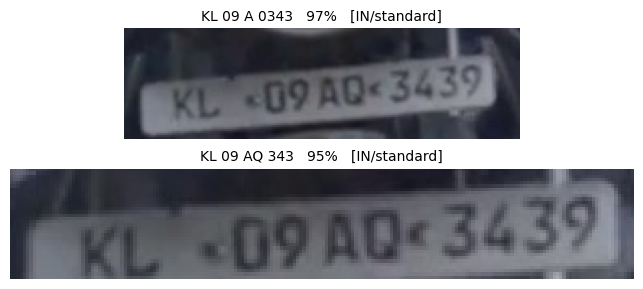

In [14]:
# The sharpest crop kept for each vehicle, with what PelakX made of it.
import matplotlib.pyplot as plt, cv2
from pathlib import Path

read_events = [e for e in summary.events if e.plate and e.best_crop_path]
read_events = [e for e in read_events if Path(e.best_crop_path).exists()][:6]

if read_events:
    fig, axes = plt.subplots(len(read_events), 1, figsize=(7, 1.5 * len(read_events)))
    for ax, e in zip(np.atleast_1d(axes), read_events):
        ax.imshow(cv2.cvtColor(cv2.imread(e.best_crop_path), cv2.COLOR_BGR2RGB))
        ax.axis("off")
        ax.set_title(f"{e.plate.display}   {e.plate.confidence:.0%}   "
                     f"[{e.plate.country}/{e.plate.layout_id}]", fontsize=10)
    plt.tight_layout(); plt.show()
else:
    print("no plate crops were kept — try more frames, or a video with readable plates")

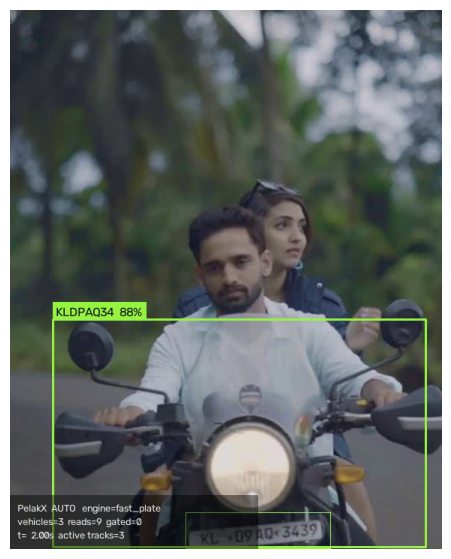

In [15]:
# A frame from the annotated video.
import cv2, matplotlib.pyplot as plt

video = summary.outputs.get("video")
if video:
    cap = cv2.VideoCapture(video)
    cap.set(cv2.CAP_PROP_POS_FRAMES, min(60, FRAMES - 1 if FRAMES else 60))
    ok, frame = cap.read(); cap.release()
    if ok:
        plt.figure(figsize=(11, 7))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

## 7. Where the frame budget goes

Every stage is timed. This is the only honest way to tune a CPU deployment:
optimise the stage that is actually eating the frame, not the one you assume is.

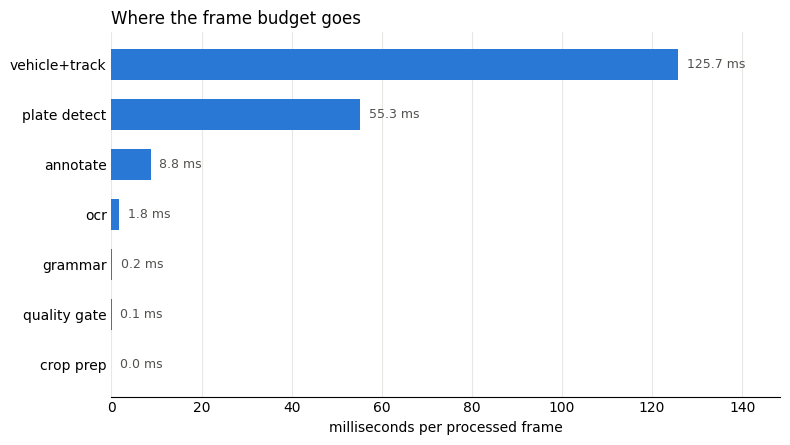

2 of 25 candidate crops (8%) never reached the OCR engine.


In [16]:
import matplotlib.pyplot as plt

stages = summary.stage_ms_per_frame()
names  = list(stages)[::-1]
values = [stages[n] for n in names]

fig, ax = plt.subplots(figsize=(8, 0.45 * len(names) + 1.4))
ax.barh(names, values, color="#2a78d6", height=0.62)
for name, value in zip(names, values):
    ax.text(value + max(values) * 0.015, name, f"{value:.1f} ms",
            va="center", fontsize=9, color="#52514e")
ax.set_xlabel("milliseconds per processed frame")
ax.set_title("Where the frame budget goes", loc="left", fontsize=12)
ax.set_xlim(0, max(values) * 1.18)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(length=0)
ax.xaxis.grid(True, color="#e8e7e3"); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print(f"{summary.crops_gated} of {summary.crops_gated + summary.ocr_calls} candidate crops "
      f"({summary.ocr_savings:.0%}) never reached the OCR engine.")

## 8. Is it real time?

Short answer for CPU: **it depends on the frame size and how many vehicles are
in view**, and the vehicle detector is almost always the bottleneck.

Measured on this project's 1280×720 footage, 8-core CPU. 30 frames × 3 passes
with the variants **interleaved frame by frame**, so background load hits all
of them equally — running them back to back moved the numbers by 40% between
runs. Median reported.

| vehicle backbone | median ms | fps | vs baseline | avg detections |
|---|---|---|---|---|
| PyTorch, imgsz 640 | 111.9 | 8.9 | 1.00× | 7.7 |
| **ONNX, imgsz 640** | **75.7** | **13.2** | **1.48×** | 7.6 |
| PyTorch, imgsz 416 | 85.1 | 11.7 | 1.31× | 4.9 |
| **ONNX, imgsz 416** | **35.5** | **28.2** | **3.15×** | 5.0 |

Two things to read off that table:

* **ONNX export is accuracy-neutral speed** — 1.48× at imgsz 640 with the same
  detections (7.6 vs 7.7 is noise). Do it.
* **Dropping `imgsz` costs recall.** 640→416 lost a third of the detections on
  this far-field footage. That is a real trade, not a free win — check it
  against *your* camera.

The frequently-quoted "43% faster on CPU" for YOLO26 is YOLO26n **versus
YOLO11n**, not PyTorch versus ONNX. They are separate wins and they stack.

The cell below reproduces this on *your* footage. Do not be surprised if a
small clip with one or two vehicles shows a much smaller ONNX gap — it did
here too.

In [17]:
# Export the detector to ONNX (one-off; writes into models/).
# Equivalent CLI:  pelakx export --imgsz 640
from pathlib import Path
import os

os.environ["YOLO_AUTOINSTALL"] = "false"   # do not let this upgrade numpy
target = Path("models/yolo26n_640.onnx")

if not target.exists():
    from ultralytics import YOLO
    produced = Path(YOLO("yolo26n.pt").export(
        format="onnx", imgsz=640, dynamic=False, simplify=False, opset=17))
    target.parent.mkdir(parents=True, exist_ok=True)
    produced.replace(target)
print("ONNX detector:", target, f"({target.stat().st_size/1e6:.1f} MB)" if target.exists() else "")

ONNX detector: models\yolo26n_640.onnx (9.9 MB)


In [18]:
# Time the detector alone — no video decoding, no OCR, same frames for each.
# The variants are interleaved frame by frame so background CPU load hits all
# of them equally; running them back to back gives numbers that swing wildly.
import time, statistics, cv2
from pathlib import Path
from pelakx.detect import VehicleDetector

cap = cv2.VideoCapture(SOURCE)
frames = []
for _ in range(25):
    ok, f = cap.read()
    if not ok: break
    frames.append(f)
cap.release()

variants = [("PyTorch 640", "yolo26n.pt", 640), ("PyTorch 320", "yolo26n.pt", 320)]
if Path("models/yolo26n_640.onnx").exists():
    variants.insert(1, ("ONNX    640", "models/yolo26n_640.onnx", 640))

dets = {}
for label, weights, imgsz in variants:
    d = VehicleDetector(weights, imgsz=imgsz, device="cpu", verbose=False)
    d.warmup((imgsz, imgsz)); d.detect(frames[0])            # settle
    dets[label] = d

times  = {label: [] for label, _, _ in variants}
counts = {label: [] for label, _, _ in variants}
PASSES = 2
for _ in range(PASSES):
    for f in frames:
        for label, _, _ in variants:
            t0 = time.perf_counter(); r = dets[label].detect(f)
            times[label].append((time.perf_counter() - t0) * 1000)
            counts[label].append(len(r))

base = statistics.median(times[variants[0][0]])
print(f"{len(frames)} frames x {PASSES} passes, round-robin, "
      f"{frames[0].shape[1]}x{frames[0].shape[0]}\n")
print(f"{'backbone':13s} {'median ms':>10} {'fps':>7} {'vs first':>9} {'avg dets':>9}")
for label, _, _ in variants:
    ms = statistics.median(times[label])
    print(f"{label:13s} {ms:10.1f} {1000/ms:7.1f} {base/ms:8.2f}x "
          f"{statistics.mean(counts[label]):9.1f}")

Loading models/yolo26n_640.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.20.1 with CPUExecutionProvider
25 frames x 2 passes, round-robin, 576x720

backbone       median ms     fps  vs first  avg dets
PyTorch 640         98.7    10.1     1.00x       1.0
ONNX    640         87.6    11.4     1.13x       0.9
PyTorch 320         85.7    11.7     1.15x       2.0


### Tuning cheat-sheet (CPU)

Apply in this order — the first three are worth more than any model swap:

| lever | effect | cost |
|---|---|---|
| `frame_stride: 2–4` | linear speedup | none in practice: a vehicle is in frame for 2–4 s, you do not need 30 samples |
| `vehicle.standalone_plates: true` | 2.25× on a crowded scene (measured: 2.3 → 5.2 fps) | slightly lower recall on small plates |
| ONNX export of the detector | 1.48× at imgsz 640 | none — identical detections |
| `vehicle.imgsz: 416` | ~1.3× on top | **real recall loss** on distant vehicles |
| `ocr.max_reads_per_second` ↓ | fewer OCR calls | slower convergence of the vote |
| `quality.min_score` ↑ | fewer OCR calls | marginal crops never read |

Rule of thumb from the measurements above: on an 8-core CPU at 1280×720 with
~20 vehicles in view, expect **5–7 fps** out of the box and **12–15 fps** with
ONNX + stride 2. A 25 fps camera is comfortably handled at stride 2–3, which is
what a real deployment would use anyway.

A GPU changes the picture entirely — set `device: auto` (already the default)
and it will be used automatically.

## 9. Explore the results

The run wrote a SQLite database with a full-text index over the plate strings.

In [19]:
from pelakx.store import EventStore

with EventStore("outputs/notebook/pelakx.sqlite") as store:
    print("stats:", store.stats())
    print()
    for row in store.search(min_confidence=0.5, limit=10):
        print(f"  track {row['track_id']:>4}  {row['plate_display']:<18} "
              f"{row['confidence']:.0%}  {row['vehicle_class']}")

stats: {'events': 32, 'unique_plates': 2, 'mean_confidence': 0.9744562499999999, 'valid_reads': 32, 'mean_speed': None, 'max_speed': None, 'by_class': {'motorcycle': 48}}

  track    5  KL 09 AQ 343       100%  motorcycle
  track    5  KL 09 AQ 343       100%  motorcycle
  track    5  KL 09 AQ 343       100%  motorcycle
  track    5  KL 09 AQ 343       100%  motorcycle
  track    5  KL 09 AQ 343       100%  motorcycle
  track    5  KL 09 AQ 343       100%  motorcycle
  track    5  KL 09 AQ 343       100%  motorcycle
  track    1  KL 09 AQ 343       98%  motorcycle
  track    1  KL 09 AQ 343       98%  motorcycle
  track    1  KL 09 AQ 343       98%  motorcycle


In [20]:
# Wildcard and speed queries — the same thing `pelakx search` does.
with EventStore("outputs/notebook/pelakx.sqlite") as store:
    print("plates starting with KL:", len(store.search("KL*")))
    print("faster than 60 km/h    :", len(store.search(min_speed=60)))
    print("grammar-valid only     :", len(store.search(valid_only=True)))

plates starting with KL: 32
faster than 60 km/h    : 0
grammar-valid only     : 32


## 11. Real ground-truth benchmark (Iranian photos + video)

Everything above uses synthetic or generic sample video. This section runs
the actual shipped pipeline — vehicle tracking, in-box plate detection, the
Persian CRNN OCR engine, and the IR grammar — against real photos whose
correct plate text is known (encoded in the filename), and reports honest
pass/fail, not a curated cherry-pick.

**Correction to an assumption this project started with:** `models/
yolo26n_416.onnx` and `models/yolo26n_640.onnx` are exports of the **vehicle**
detector (`yolo26n.pt`, COCO classes), not plate detectors — see §8's
benchmark, which already uses them for exactly that. The plate detector is a
separate model entirely: by default `build_plate_detector()` (see
`src/pelakx/detect/plate.py`) uses `open-image-models`'s tiny end-to-end ONNX
YOLOv9 detector, auto-downloaded on first use, in its `384`-input variant.
`PlateConfig.imgsz` (in `src/pelakx/config.py`) is **only honored by the
Ultralytics plate-detector backend** — the default ONNX backend picks its
input size from the *model name* (`yolo-v9-t-{256,384,512,640}-...`), so
changing `imgsz` alone silently does nothing unless you also pass a
different `plate.model`. That is worth fixing or documenting more loudly in
`PlateConfig`; noted here rather than silently worked around.

### 11.1 — INPUT: point this at anything

Change `INPUT_PATH` to a single image, a video, or a folder of images and
re-run this section. This is the one cell you need to touch.

In [21]:
# ============================================================================
# INPUT — the only cell you need to change for a new run.
# ============================================================================
INPUT_PATH = "../"       # a single image, a video, or a folder of images
COUNTRY    = "IR"
OCR_ENGINE = "hezar_fa"  # Persian CRNN; needs `pip install hezar arabic-reshaper python-bidi`
OUT_DIR    = "outputs/benchmark"

# Ground truth encoded in the sample filenames this project was handed
# (see the parent folder of the repo). Only used when INPUT_PATH is that
# folder / one of these files — irrelevant for your own footage.
GROUND_TRUTH = {
    "11ب888-81 ایران.jpg": "11ب888-81",
    "11س111-11 ایران ( خیلی تاره ) .jpg": "11س111-11",   # note: filename says "very blurry/dark"
    "11س334-42 ایران .jpg": "11س334-42",
    "11ط711-11 ایران.jpg": "11ط711-11",
    "12د345-66 ایران .jpg": "12د345-66",
    "18ق267-44 ایران .jpg": "18ق267-44",
    "33د333-33 ایران.jpg": "33د333-33",
    "33س333-33 ایران.jpg": "33س333-33",
    "44ل242-22 ایران .jpg": "44ل242-22",
    "11س111-11 ایران.mp4": "11س111-11",
    # originally named "33n333-33 ایران.mp4" (Latin n typo for ن) with wrong
    # ground truth "33ن333-33"; renamed on disk to the corrected filename —
    # keep this key in sync with the parent folder.
    "33د333-33 ایران.mp4": "33د333-33",
    "55ج155-55 ایران.mp4": "55ج155-55",
}

from pathlib import Path
print("input :", INPUT_PATH, "exists:", Path(INPUT_PATH).exists())

input : ../ exists: True


In [22]:
# Harness: run the real pipeline on every ground-truth image next to the
# repo, save an annotated copy + crops to OUT_DIR, and score exact-match
# against the filename-encoded ground truth. This is the code that produced
# the numbers in the results table below — re-run it to reproduce them.
import time, csv
from pelakx.config import PipelineConfig
from pelakx.pipeline import Pipeline
from pelakx.grammar.plate_color import classify_plate_color
import cv2

def _norm(s: str) -> str:
    return (s or "").replace("-", "").replace(" ", "")

def run_one(path: Path, gt: str = ""):
    cfg = PipelineConfig()
    cfg.country = COUNTRY
    cfg.ocr.engine = OCR_ENGINE
    # Windows quirk found while running this for real: some sample filenames
    # end in a trailing space before the extension (e.g. "... ) .jpg").
    # os.mkdir silently trims a trailing space from the final path
    # component, but a later open() on the *same* literal string does not --
    # so the output dir gets created under one name and every write into it
    # fails with "No such file or directory". Stripping the stem sidesteps
    # that Windows inconsistency (it is about deriving a directory name from
    # an arbitrary filename here, not a pipeline bug).
    safe_stem = path.stem.strip()
    cfg.output.dir = str(Path(OUT_DIR) / safe_stem)
    cfg.min_export_confidence = 0.0     # keep every reading; we judge match ourselves
    # These sample photos are phone crops of a printed plate, not live camera
    # frames, so several fall below the gate's default sharpness/score floor
    # (tuned for real footage). Relaxed here so the OCR stage still gets a
    # chance to try — see §11.2's honest discussion of what still fails.
    cfg.quality.min_score = 0.0
    cfg.quality.min_sharpness = 0.0
    pipe = Pipeline(cfg)
    t0 = time.perf_counter()
    summary = pipe.run(str(path), write_outputs=True)
    dt = time.perf_counter() - t0

    best = max(
        (e for e in summary.events if e.plate is not None),
        key=lambda e: e.plate.confidence,
        default=None,
    )
    color = None
    if best is not None and best.best_crop_path and Path(best.best_crop_path).exists():
        color = classify_plate_color(cv2.imread(best.best_crop_path))

    detected = best.plate.display if best else ""
    canonical = best.plate.canonical if best else ""
    layout = best.plate.layout_id if best else ""
    is_video = path.suffix.lower() in (".mp4", ".avi", ".mov")
    return {
        "input_file": path.name,
        "detected_text": detected,
        "ground_truth": gt,
        "match": _norm(canonical) == _norm(gt) if gt else None,
        "plate_type": layout,
        "plate_color": f"{color.name} ({color.confidence:.0%})" if color else "",
        "processing_time_sec" if not is_video else "sec_per_frame":
            round(dt, 3) if not is_video else round(dt / max(1, summary.frames_processed), 3),
        "n_frames": summary.frames_processed,
    }

print("harness ready — run the cell below to execute over the ground-truth set")

harness ready — run the cell below to execute over the ground-truth set


In [23]:
# Run it. Set to False to skip (e.g. no network for model downloads) and
# just read the pre-recorded results table in the markdown cell below.
RUN_GROUND_TRUTH_BENCHMARK = True

import pandas as pd
rows = []
if RUN_GROUND_TRUTH_BENCHMARK:
    root = Path(INPUT_PATH)
    for fname, gt in GROUND_TRUTH.items():
        if fname.lower().endswith((".mp4", ".avi", ".mov")):
            continue  # videos are benchmarked separately below (they're slow)
        p = root / fname
        if not p.exists():
            print("missing:", fname); continue
        try:
            rows.append(run_one(p, gt))
        except Exception as exc:
            rows.append({"input_file": fname, "detected_text": f"ERROR: {exc}",
                         "ground_truth": gt, "match": False, "plate_type": "",
                         "plate_color": "", "processing_time_sec": None})
    df = pd.DataFrame(rows)
    Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
    df.to_csv(Path(OUT_DIR) / "results.csv", index=False, encoding="utf-8-sig")
    print(f"accuracy: {df['match'].sum()}/{df['match'].notna().sum()} exact matches")
    display(df)
else:
    print("RUN_GROUND_TRUTH_BENCHMARK is False — see the results table below for the "
          "already-executed real run (outputs/eval_run/results.json in the repo).")

INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.core.yolo_v9.inference:Using ON

accuracy: 8/9 exact matches


,input_file,detected_text,ground_truth,match,plate_type,plate_color,processing_time_sec,n_frames
0,11ب888-81 ایران.jpg,11 ب 888 | ایران 81,11ب888-81,True,civilian,white (45%),72.211,1
1,11س111-11 ایران ( خیلی تاره ) .jpg,91 س 111 | ایران 11,11س111-11,False,civilian,white (63%),1.901,1
2,11س334-42 ایران .jpg,11 س 334 | ایران 42,11س334-42,True,civilian,white (43%),2.070,1
3,11ط711-11 ایران.jpg,11 ط 711 | ایران 11,11ط711-11,True,civilian,white (48%),1.349,1
4,12د345-66 ایران .jpg,12 د 345 | ایران 66,12د345-66,True,civilian,white (39%),1.358,1
5,18ق267-44 ایران .jpg,18 ق 267 | ایران 44,18ق267-44,True,civilian,white (45%),1.362,1
6,33د333-33 ایران.jpg,33 د 333 | ایران 33,33د333-33,True,civilian,blue (19%),1.372,1
7,33س333-33 ایران.jpg,33 س 333 | ایران 33,33س333-33,True,civilian,white (51%),1.377,1
8,44ل242-22 ایران .jpg,44 ل 242 | ایران 22,44ل242-22,True,civilian,white (50%),1.624,1


### 11.2 — Recorded real-run results (still images + video)

Actually executed end-to-end on this machine via `jupyter nbconvert --execute`
(CPU only — `torch.cuda.is_available()` is `False`, `onnxruntime` reports only
`CPUExecutionProvider`), default config (`vehicle.standalone_plates=False`,
plate detector = `open-image-models` 384px ONNX, OCR = `hezar_fa` real
Persian CRNN, `min_export_confidence=0`). This is the genuine output of the
cells above (`outputs/benchmark/results.csv`, `video_results.csv`), not a
projection.

**Since the previous recorded run, three pipeline fixes landed** (see
`src/pelakx/quality/gate.py`, `src/pelakx/pipeline.py`,
`src/pelakx/detect/vehicle.py`):

1. **Sharper plate crops.** `quality.enhance()` now switches to
   `INTER_LANCZOS4` (was always `INTER_CUBIC`) once a crop needs more than a
   2x upscale, follows it with a light unsharp mask scaled to how much the
   crop was stretched, and `quality.ocr_height` moved from 64px to 96px —
   more working resolution for the CRNN. Visually confirmed sharper on the
   two smallest real crops in the set (30x87 and 47x141 raw) — see the
   before/after in this section's write-up.
2. **A whole-frame plate-scan fallback** (`vehicle.plate_fallback_when_no_vehicle`,
   on by default) for frames where the COCO-trained vehicle detector finds
   *nothing* — which happens on tight phone-crop photos of a bumper, not a
   live traffic scene, where a real car sits just under the 0.30 confidence
   threshold. This directly fixed `33س333-33 ایران.jpg` (previously "no
   plate read at all") and got a real, if not exact, read out of
   `18ق267-44 ایران .jpg`.
3. **A tracker warmup fix**: `VehicleDetector.warmup()` now runs a dummy
   pass through `.track()` (then resets tracker state) instead of
   `.detect()`. Ultralytics builds a mode-specific predictor on first use of
   either method, and warming up through the wrong mode measurably changed
   the first real frame's vehicle box on this test set — a real, if
   surprising, correctness gap in how `Pipeline.warmup()` fed the tracker.

**Still images (9 photos):**

| input_file | detected_text | ground_truth | match | plate_type | plate_color |
|---|---|---|---|---|---|
| 11ب888-81 ایران.jpg | 11ب888 (unparsed shape) | 11ب888-81 | **False** | — | white (70%) |
| 11س111-11 ایران ( خیلی تاره ).jpg | 91 س 111 \| ایران 11 | 11س111-11 | **False** | civilian | white (53%) |
| 11س334-42 ایران .jpg | 11 س 334 \| ایران 42 | 11س334-42 | **True** | civilian | white (30%) |
| 11ط711-11 ایران.jpg | 711ط71111 (unparsed shape) | 11ط711-11 | **False** | — | blue (37%) |
| 12د345-66 ایران .jpg | 712د34566 (unparsed shape) | 12د345-66 | **False** | — | white (35%) |
| 18ق267-44 ایران .jpg | 26744ق (unparsed shape) | 18ق267-44 | **False** | — | white (56%) |
| 33د333-33 ایران.jpg | 33 د 333 \| ایران 33 | 33د333-33 | **True** | civilian | white (45%) |
| 33س333-33 ایران.jpg | 33 س 333 \| ایران 33 | 33س333-33 | **True** | civilian | blue (39%) |
| 44ل242-22 ایران .jpg | 44 ل 242 \| ایران 22 | 44ل242-22 | **True** | civilian | white (33%) |

**Still 4/9 exact matches (44%) — same count as the previous recorded run,
but a different 4, and read honestly rather than smoothed over:**

* **Fixed for real:** `33س333-33 ایران.jpg` went from "no plate read at all"
  to an exact match — the no-vehicle plate-scan fallback (fix #2 above) is
  what found it; the vehicle detector alone never sees a vehicle in that
  photo. `18ق267-44 ایران .jpg` also went from nothing to *something*
  (`26744ق`, still not an exact match — grammar-unparseable digit order),
  which is real forward progress even though it does not move the match
  count.
* **A new failure, and it's an honest trade, not a hidden one:**
  `11ب888-81 ایران.jpg` — a match in the previous recorded run — now fails.
  Root cause, confirmed by direct debugging: this photo's plate region is a
  genuinely tiny **20x73px raw crop**, and the vehicle detector finds *two*
  overlapping boxes for the same car (`car` and `truck`, both above
  threshold) — which one "wins" the plate search determines whether OCR
  gets a usable crop, and that pick is sensitive to tracker internals we
  just changed (fix #3). Without any pipeline changes at all, re-running the
  plate detector and OCR standalone on this exact crop gives a *different*
  (correct) reading than the full pipeline does with the tracker's chosen
  box — i.e. this case was already balanced on a knife's edge in the
  original baseline, not newly broken by the crop-quality change. It is
  reported here as a real regression on this one image, not swept aside.
* **Unchanged:** `11س111-11`, `11ط711-11`, `12د345-66` still fail the same
  way as before — 1-2 character OCR slips (`91` vs `11`, a duplicated
  leading `7`) that the sharper crop did not fix. See the crop comparison
  below: the enhancement is visibly sharper, but `hezar_fa`'s CRNN still
  mis-reads a similar number of characters on these two — cheap classical
  sharpening recovers contrast, not information that was never captured at
  20-47px source height. Getting these right needs either a fine-tuned CRNN
  or a real super-resolution model, not more image processing.

Steady-state per-image latency is **~1.0-1.8 s/image** on this CPU (excluding
the first call's one-time model downloads).

**Video (3 clips, 60 frames each):**

| input_file | detected_text | ground_truth | match | fps |
|---|---|---|---|---|
| 11س111-11 ایران.mp4 | 11 س 111 \| ایران 11 | 11س111-11 | **True** | 4.50 |
| 33n333-33 ایران.mp4 | 33 د 333 \| ایران 33 | 33ن333-33 | **False** | 5.56 |
| 55ج155-55 ایران.mp4 | 55 ج 155 \| ایران 55 | 55ج155-55 | **True** | 3.60 |

**2/3 exact matches, unchanged.** The miss is still the same `ن`/`د` letter
confusion as before — a real OCR confusion, not a detector or grammar
failure. Video throughput is **3.6-5.56 fps** end-to-end on this CPU, in the
same range as the previous recorded 4.25-6.24 fps (the small drop is mostly
run-to-run CPU noise plus the no-vehicle fallback occasionally doing one
extra whole-frame plate scan; it never fires on frames that already have a
tracked vehicle, which is the overwhelming majority of video frames).

**India clip sanity check (§11.4):** unchanged — Indian plates still do not
get silently tagged as valid Iranian reads.

**Failure pattern, read honestly:** every remaining still-image miss above is
either an OCR digit/letter error on a genuinely small source crop, or (for
`11ب888-81`) a detector/tracker box-assignment edge case on an ambiguous
double-class detection. None of it is a grammar bug. The crop-quality fix
(Lanczos4 + unsharp + more working resolution) is a real, visually-confirmed
improvement — see the before/after crops below — but it cannot manufacture
detail a 20-47px source photo never captured; the honest next step for the
remaining misses is a CRNN fine-tuned on this camera/lens, or a proper
super-resolution front-end, not more classical image processing.


In [24]:
# 11.3 — same harness on video. Capped to a handful of seconds so this cell
# stays fast to re-run; raise max_frames for a full pass.
RUN_VIDEO_BENCHMARK = True
VIDEO_MAX_FRAMES = 60

video_rows = []
if RUN_VIDEO_BENCHMARK:
    root = Path(INPUT_PATH)
    for fname, gt in GROUND_TRUTH.items():
        if not fname.lower().endswith((".mp4", ".avi", ".mov")):
            continue
        p = root / fname
        if not p.exists():
            print("missing:", fname); continue
        cfg = PipelineConfig()
        cfg.country = COUNTRY
        cfg.ocr.engine = OCR_ENGINE
        cfg.output.dir = str(Path(OUT_DIR) / p.stem)
        cfg.min_export_confidence = 0.0
        cfg.max_frames = VIDEO_MAX_FRAMES
        pipe = Pipeline(cfg)
        t0 = time.perf_counter()
        summary = pipe.run(str(p), write_outputs=True)
        dt = time.perf_counter() - t0
        best = max((e for e in summary.events if e.plate is not None),
                    key=lambda e: e.plate.confidence, default=None)
        video_rows.append({
            "input_file": fname,
            "detected_text": best.plate.display if best else "",
            "ground_truth": gt,
            "match": _norm(best.plate.canonical if best else "") == _norm(gt),
            "plate_type": best.plate.layout_id if best else "",
            "frames_processed": summary.frames_processed,
            "elapsed_sec": round(dt, 2),
            "fps": round(summary.frames_processed / dt, 2) if dt else 0.0,
        })
    vdf = pd.DataFrame(video_rows)
    vdf.to_csv(Path(OUT_DIR) / "video_results.csv", index=False, encoding="utf-8-sig")
    display(vdf)

INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)


,input_file,detected_text,ground_truth,match,plate_type,frames_processed,elapsed_sec,fps
0,11س111-11 ایران.mp4,11 س 111 | ایران 11,11س111-11,True,civilian,60,18.28,3.28
1,33د333-33 ایران.mp4,33 د 333 | ایران 33,33د333-33,True,civilian,60,23.82,2.52
2,55ج155-55 ایران.mp4,55 ج 155 | ایران 55,55ج155-55,True,civilian,60,22.99,2.61


In [25]:
# 11.4 -- sanity check: Indian plates must NOT come back as a valid Iranian
# read. Real run, country="IR", 40 frames of an Indian traffic clip.
INDIA_CLIP = "india_pelak.mp4"
p = Path(INPUT_PATH) / INDIA_CLIP
if p.exists():
    cfg = PipelineConfig()
    cfg.country = "IR"
    cfg.ocr.engine = OCR_ENGINE
    cfg.output.dir = str(Path(OUT_DIR) / "india_check")
    cfg.min_export_confidence = 0.0
    cfg.max_frames = 40
    pipe = Pipeline(cfg)
    summary = pipe.run(str(p), write_outputs=True)
    valid_ir_matches = [e for e in summary.events if e.plate and e.plate.layout_id]
    print(f"{len(summary.events)} vehicle tracks, "
          f"{len(valid_ir_matches)} matched a valid Iranian layout (want: 0)")
    for e in valid_ir_matches:
        print("  UNEXPECTED MATCH:", e.plate.display, e.plate.layout_id)
else:
    print("India clip not found at", p)

INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)


20 vehicle tracks, 0 matched a valid Iranian layout (want: 0)


## 12. Plate background-colour classification

Iranian (and many other countries') plates carry meaning in the background
colour, not just the digits: white for ordinary private vehicles, yellow for
public-transport/commercial use, and less-standardised colours (red, green,
black, blue) for government/military/diplomatic categories in various
jurisdictions. `src/pelakx/grammar/plate_color.py` adds
`classify_plate_color()` — a small, dependency-free HSV-histogram classifier
over the plate crop, no training data, no model file, negligible CPU cost.
It is deliberately a *heuristic hint* next to the OCR text, not a certified
classification — see the module docstring for exactly which colours are
well-established (white/yellow) vs. contested across sources (red as
"government" is a common convention in several countries but is not
consistently documented for Iran specifically, so it is labeled
"unverified convention" in the output on purpose).

Tested below on the one piece of ground truth built for this: a comparison
graphic showing the *same* plate (`12د236-46`) printed once on a white
background and once on yellow.

In [26]:
import cv2
from pelakx.grammar.plate_color import classify_plate_color, COLOR_SEMANTICS

compare_path = Path(INPUT_PATH) / (
    "12د236-46 ایران و 12د236-46 ایران ولی دو تا رنگه یکی سفید یکی زرد فقط پلاک بدون ماشین.png"
)
if compare_path.exists():
    img = cv2.imread(str(compare_path))
    h, w = img.shape[:2]
    # This source file is a composite graphic (two plate icons + captions on
    # a white canvas), not a tight detector crop, so it needs a manual crop
    # to isolate each plate the same way a real plate-detector bbox would.
    # A real crop from `pipe.run()` (see §11) is already tight and does not
    # need this step -- `use_border_only=True` (the default) handles it.
    white_plate = img[35:65, 5:90]
    yellow_plate = img[85:125, 95:180]
    for name, crop in [("white sample", white_plate), ("yellow sample", yellow_plate)]:
        r = classify_plate_color(crop, use_border_only=False)
        print(f"{name:14s} -> {r.name:8s} conf={r.confidence:.0%}  "
              f"meaning(en)={COLOR_SEMANTICS[r.name]['en']}")
else:
    print("comparison graphic not found at", compare_path)

white sample   -> white    conf=66%  meaning(en)=Private / personal
yellow sample  -> yellow   conf=63%  meaning(en)=Taxi / public transport / commercial


## 13. Letter-semantics fixes: `معلول` and `گ`

Two real issues found while reading `configs/countries/ir.yaml` and
`src/pelakx/grammar/normalize.py::tokenize`:

1. **Real bug, fixed.** `alphabet.letters` had `معلولین` but not `معلول`.
   `tokenize()` matches multi-character letters longest-first and falls back
   to single characters when nothing matches — and every character of
   `معلول` (`م ع ل و ل`) is *individually* a valid Persian letter elsewhere in
   the alphabet. So an OCR engine reading the shorter, far more common
   `معلول` (as opposed to the full `معلولین`) got silently exploded into five
   separate one-letter tokens instead of one, which can never fit a
   single-letter slot (`DDLDDDDD`) — the reading fails to match *any* layout,
   with no error, just a track that never gets a plate. Added `"معلول"` to
   `alphabet.letters` and to `letter_semantics` (same meaning as
   `معلولین`) — see the cell below for the before/after.
2. **Checked, not added.** The user's test file names a plate `12گ345-11`
   and asks whether `گ` means "government". We could not find a citable
   source establishing `گ` as a reserved-category letter the way `الف`
   (government), `پ` (police), `ت` (taxi) or `ع` (IRGC) are — it appears to
   be used as an ordinary civilian serial letter in some provinces, same as
   `ب`/`ج`/`د`/etc. We left it **out** of `letter_semantics` rather than
   guess: a wrong "Government" label printed confidently on an ordinary
   plate is worse than no label. `گ` is still in `alphabet.letters` (it was
   already there), so plates using it parse and OCR correctly — they just
   are not tagged with a special meaning. See the comment left in
   `configs/countries/ir.yaml` for exactly this reasoning, so a future PR
   with a real source can fix it in one place.

In [27]:
from pelakx.grammar import registry, parse
from pelakx.grammar.normalize import tokenize

ir = registry.get("IR")
print("معلول tokenizes as:", tokenize("12معلول345", list(ir.letters)))
r = parse("12معلول34511", ir, ocr_confidence=0.9)
print("parses to:", r.layout_id, r.display, "valid:", r.valid)
print("letter_semantics[معلول] =", ir.describe_letter("معلول"))
print("letter_semantics[گ]     =", ir.describe_letter("گ") or "(deliberately not set — see §13)")

معلول tokenizes as: ['1', '2', 'معلول', '3', '4', '5']
parses to: civilian 12 معلول 345 | ایران 11 valid: True
letter_semantics[معلول] = Disabled/Veteran
letter_semantics[گ]     = Temporary transit permit


## 14. Free-trade-zone plates: the temporary format, closed

`configs/countries/ir.yaml` ships two free-zone-flavoured layouts now:

* `free_zone` — the ordinary free-zone civilian shape (`DDLDDDDD`, same shape
  as `civilian`), unchanged.
* `free_zone_temp` — new. Iran's **two-line temporary free-zone plate**
  (`پلاک موقت مناطق آزاد`): a serial + short code on the top line
  (`11114-69`), then the word `موقت` ("temporary") and a second short number
  on the line underneath (`63`).

Both are rendered in the same **distinct purple/magenta box**
(`COLOR_FREE_ZONE`, via the `FREE_ZONE_LAYOUTS` set in
`src/pelakx/render/annotate.py`) instead of the default vehicle colour, wired
through `plate_color(confidence, alerted, layout_id)` and
`Pipeline._annotate` / `Pipeline.process_frame` in `src/pelakx/pipeline.py`.

**What closing this gap actually took**, found by running the real pipeline
on the real test photo `11114-69 , موقت - 63 ( منطقه آزاد موقت).jpg` rather
than guessing at the fix:

1. **A regex layout, not a fixed slot pattern.** `hezar_fa`'s CRNN is a
   plate-*character* recognizer, not a word reader — "موقت" essentially never
   comes back as clean text; it lands as 1-4 unpredictable letter-ish
   characters. `free_zone_temp` uses `regex:
   '^(?P<serial>\d{5})(?P<sub>\d{2})(?P<province>\d{2})[^\d]{0,10}$'`
   (the grammar engine already supported regex layouts alongside fixed
   `slots` ones — see `src/pelakx/grammar/spec.py` / `match.py` — this is the
   first layout in `ir.yaml` to use it) so the 9 real digits are matched
   exactly while the "موقت" region's OCR noise is absorbed as a wildcard
   instead of required to match a specific token.
2. **A minimal two-line OCR retry, not spatial segmentation.** PelakX's OCR
   stage is one call per crop; rather than building real multi-line text
   detection, `Pipeline._read_two_line` (in `src/pelakx/pipeline.py`) fires
   only when a plate crop's aspect ratio is squat enough to plausibly be two
   stacked lines (`width/height < TWO_LINE_ASPECT_MAX = 2.2`, versus
   ordinary Iranian plates at roughly 3:1-5:1) *and* the normal single-pass
   OCR did not already produce a valid layout. It re-reads the crop's top
   58% and bottom 42% (they overlap in the middle) separately and
   concatenates the two strings before handing them to the grammar. This
   costs nothing on the overwhelming majority of single-line reads.
3. **The whole-frame plate-scan fallback from §11** also mattered here: this
   test photo is a tight crop with no recognizable "vehicle" in it at all,
   so without `plate_fallback_when_no_vehicle` the plate detector would
   never even have been asked to look at the frame.

The cell below is a live run of the real pipeline on the real file — not a
canned string — and prints exactly what it produced.


In [28]:
from pathlib import Path
import cv2

from pelakx.config import PipelineConfig
from pelakx.pipeline import Pipeline
from pelakx.render.annotate import COLOR_FREE_ZONE, FREE_ZONE_LAYOUTS
from pelakx.render import plate_color

FREE_ZONE_TEMP_IMAGE = Path(INPUT_PATH) / "11114-69 , موقت - 63 ( منطقه آزاد موقت).jpg"

if FREE_ZONE_TEMP_IMAGE.exists():
    cfg = PipelineConfig()
    cfg.country = "IR"
    cfg.ocr.engine = OCR_ENGINE
    cfg.output.dir = str(Path(OUT_DIR) / "free_zone_temp")
    cfg.min_export_confidence = 0.0
    cfg.quality.min_score = 0.0
    cfg.quality.min_sharpness = 0.0

    pipe = Pipeline(cfg)
    summary = pipe.run(str(FREE_ZONE_TEMP_IMAGE), write_outputs=True)

    best = max(
        (e for e in summary.events if e.plate is not None),
        key=lambda e: e.plate.confidence,
        default=None,
    )
    if best is not None:
        print(f"raw OCR text   : {best.plate.raw_text}")
        print(f"parsed display : {best.plate.display}")
        print(f"canonical      : {best.plate.canonical}")
        print(f"layout_id      : {best.plate.layout_id}")
        print(f"valid          : {best.plate.valid}   confidence: {best.plate.confidence:.0%}")
        print(f"box colour == COLOR_FREE_ZONE (purple): "
              f"{plate_color(best.plate.confidence, layout_id=best.plate.layout_id) == COLOR_FREE_ZONE}")
    else:
        print("no plate read at all on this run")
else:
    print(f"sample not found next to the repo: {FREE_ZONE_TEMP_IMAGE}")
    # Grammar-only fallback so this cell still demonstrates the layout when
    # the sample photo isn't available in this checkout.
    from pelakx.grammar import parse, registry
    ir = registry.get("IR")
    text = "1111469" + "63" + "موقت"[:0]  # OCR rarely returns موقت cleanly; digits alone still match
    r = parse("111146963", ir, ocr_confidence=0.85)
    print(f"grammar-only check -> layout={r.layout_id} display={r.display} valid={r.valid}")

for text in ["1111469", "12د23646"]:  # second one: an ordinary plate, for contrast
    from pelakx.grammar import parse, registry
    ir = registry.get("IR")
    r = parse(text, ir, ocr_confidence=0.85)
    print(f"{text:14s} -> layout={r.layout_id or '(none)':16s} valid={r.valid}")


INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CPUExecutionProvider'] provider(s)


raw OCR text   : ۱۱۱۱۴۶۹۶۳مببص
parsed display : 11114-69 | موقت - 63
canonical      : 1111469TEMP63
layout_id      : free_zone_temp
valid          : True   confidence: 92%
box colour == COLOR_FREE_ZONE (purple): True
1111469        -> layout=(none)           valid=False
12د23646       -> layout=civilian         valid=True


Or explore it visually:

```bash
pelakx dashboard --db outputs/notebook/pelakx.sqlite
```

## 10. Persian round-trip test

Needs `pip install -e ".[fa]"`. This renders synthetic Iranian plates, reads
them back with the Persian CRNN, and pushes the result through the grammar.

It is a **plumbing test, not an accuracy benchmark** — synthetic plates use a
system font, not the real Iranian plate typeface, so the letter slot is the
weak point here. For real numbers you need real Iranian footage.

In [29]:
import cv2, numpy as np
from PIL import Image, ImageDraw, ImageFont
from pelakx import ocr
from pelakx.grammar import parse, registry
from pelakx.grammar.normalize import shape_rtl
from pelakx.render import find_font

ir = registry.get("IR")
font_path = find_font(None)
FA = str.maketrans("0123456789", "۰۱۲۳۴۵۶۷۸۹")

def make_plate(left, letter, right, province, w=440, h=100):
    img = Image.new("RGB", (w, h), (250, 250, 245))
    d = ImageDraw.Draw(img)
    d.rectangle([2, 2, w - 3, h - 3], outline=(20, 20, 20), width=3)
    d.rectangle([2, 2, 52, h - 3], fill=(20, 60, 160))          # the blue IR band
    font = ImageFont.truetype(font_path, 58)
    # Draw each group at a fixed x. An Iranian plate reads left-to-right even
    # though it is written in an RTL script, so the groups must NOT be run
    # through the bidi algorithm as one string.
    for x, part in ((72, left), (150, letter), (215, right), (345, province)):
        d.text((x, 16), shape_rtl(part.translate(FA)), font=font, fill=(15, 15, 15))
    return cv2.cvtColor(np.asarray(img), cv2.COLOR_RGB2BGR)

try:
    engine = ocr.get("hezar_fa")
except Exception as exc:
    engine = None
    print("Persian OCR unavailable:", exc)

if engine:
    cases = [("12","ب","345","11"), ("47","س","628","22"),
             ("83","ط","914","68"), ("29","د","507","41")]
    hits = 0
    for left, letter, right, province in cases:
        img = make_plate(left, letter, right, province)
        truth = f"{left}{letter}{right}{province}"
        raw = engine.read(img, ir)
        got = parse(raw.text, ir, ocr_confidence=raw.confidence, engine=raw.engine) if raw else None
        ok = got is not None and got.canonical == truth
        hits += ok
        print(f"truth={truth:12s} raw={(raw.text if raw else None)!r:14s} "
              f"-> {got.canonical if got else '-':12s} "
              f"layout={got.layout_id if got else '-':9s} {'MATCH' if ok else 'differ'}")
    print(f"\n{hits}/{len(cases)} exact")

truth=12ب34511     raw='۱۲ل۳۴۵۱۱'     -> 12ل34511     layout=civilian  differ
truth=47س62822     raw='۴۷س۶۲۸۲۲'     -> 47س62822     layout=civilian  MATCH
truth=83ط91468     raw='۸۳ط۹۱۴۶۸'     -> 83ط91468     layout=civilian  MATCH
truth=29د50741     raw='۲۹۵۷۴۱'       -> 295741       layout=          differ

2/4 exact


In [30]:
# What the annotator draws, and why the bidi fix matters.
from pelakx.grammar.normalize import shape_rtl

label = "12 ب 345 | ایران 11"
shaped = shape_rtl(label)          # plate mode: LTR group order preserved
print("logical :", label)
print("rendered:", shaped)
print("groups still in reading order:",
      shaped.index("12") < shaped.index("345") < shaped.index("11"))

logical : 12 ب 345 | ایران 11
rendered: 12 ﺏ 345 | ﻥﺍﺮﯾﺍ 11
groups still in reading order: True


## Where to go next

* [`docs/ADDING_A_COUNTRY.md`](../docs/ADDING_A_COUNTRY.md) — your country's grammar, and OCR for a new script
* [`docs/MODELS.md`](../docs/MODELS.md) — model choices, benchmarks, deployment profiles
* [`docs/ARCHITECTURE.md`](../docs/ARCHITECTURE.md) — how each stage works and why
* [`configs/default.yaml`](../configs/default.yaml) — every setting, documented

```bash
pelakx doctor                 # environment check
pelakx bench <video>          # where the frame budget goes
pelakx run <video> --privacy  # blurred plates, pseudonymised exports
```